## **Analisis Komparasi Algoritma YOLO, SSD, dan Faster R-CNN untuk Deteksi Objek Pelanggaran Truk ODOL (Over Dimension Overload)**

**R-CNN**

CELL 1: Persiapan Lingkungan & Unduh Dataset

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install Library yang dibutuhkan
!pip install roboflow torchmetrics

import os
from roboflow import Roboflow

# Ganti dengan API Key milikmu
rf = Roboflow(api_key="mr4rN1CwX8na9vGEIdNh")
project = rf.workspace("indahs-workspace").project("data-indah")
version = project.version(2)
dataset = version.download("yolov8")

dataset_path = dataset.location
print(f"Dataset berhasil diunduh ke lokasi: {dataset_path}")

# Siapkan folder penyimpanan model Faster R-CNN di Drive
folder_simpan_frcnn = '/content/drive/MyDrive/Evaluasi_ODOL/FasterRCNN_Hasil'
os.makedirs(folder_simpan_frcnn, exist_ok=True)

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 101.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to data-indah-2 in yolov8:: 100%|██████████| 2865/2865 [00:00<00:00, 4686.71it/s]


Dataset berhasil diunduh ke lokasi: /content/data-indah-2


CELL 2: Exploratory Data Analysis (EDA)

📊 Memulai Proses Analisis Data Visual...



Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.


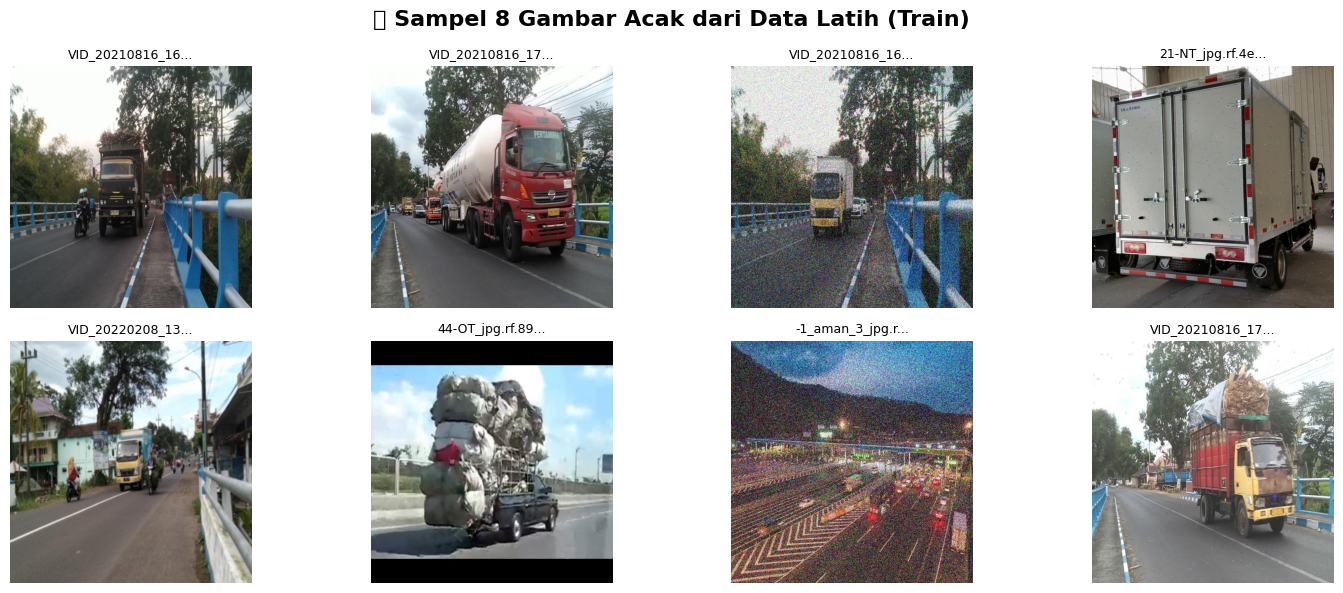

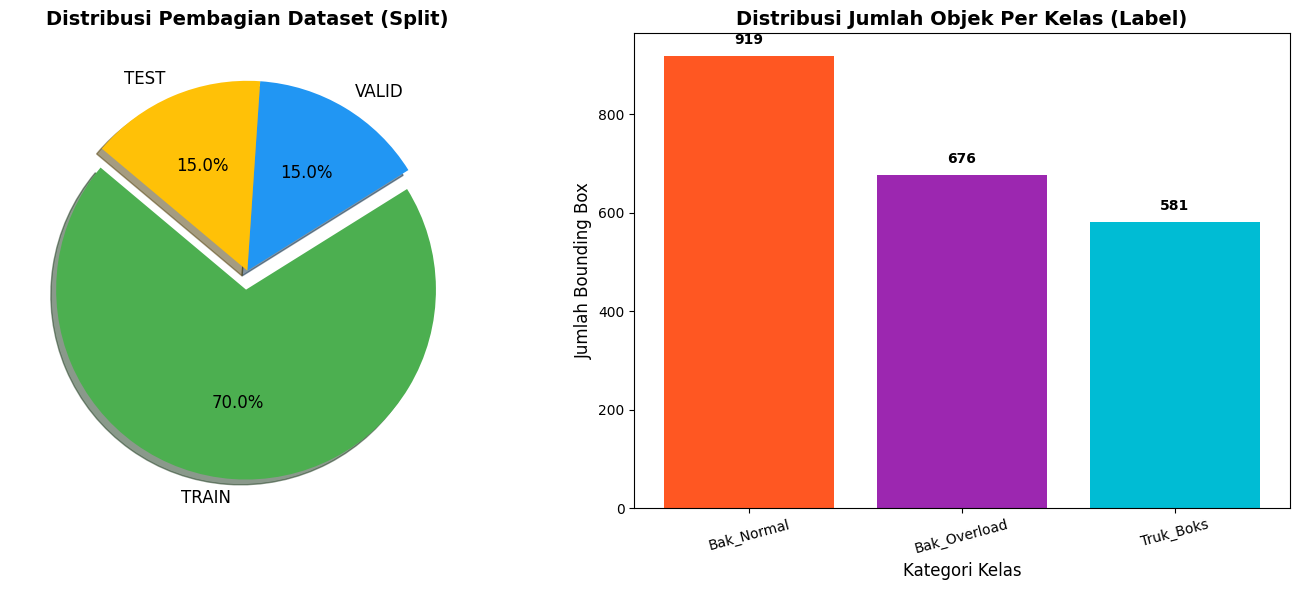


📝 RINGKASAN DATASET:
- Total Kelas Deteksi Asli : 3 Kelas (Bak_Normal, Bak_Overload, Truk_Boks)
- Total Gambar Train       : 1001 gambar
- Total Gambar Valid       : 215 gambar
- Total Gambar Test        : 214 gambar

⚠️ CATATAN PENTING UNTUK (ALGORITMA FASTER R-CNN):
Sama seperti arsitektur SSD, saat masuk ke Cell 3 (DataLoader PyTorch), algoritma Faster R-CNN akan secara otomatis menambahkan 1 kelas ekstra di memori yaitu 'Background' (Latar Belakang dengan ID 0). Sehingga total kelas operasional yang dilatih oleh model adalah 4 kelas.


In [ ]:
import os
import glob
import random
import yaml
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print("📊 Memulai Proses Analisis Data Visual...\n")

# ==========================================
# 1. VISUALISASI 8 GAMBAR ACAK DARI DATA TRAIN
# ==========================================
train_images = glob.glob(f"{dataset_path}/train/images/*.jpg")

if len(train_images) >= 8:
    gambar_acak = random.sample(train_images, 8)
    plt.figure(figsize=(15, 6))
    plt.suptitle("📸 Sampel 8 Gambar Acak dari Data Latih (Train)", fontsize=16, fontweight='bold')

    for i, img_path in enumerate(gambar_acak):
        img = mpimg.imread(img_path)
        plt.subplot(2, 4, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(os.path.basename(img_path)[:15] + "...", fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Gambar di folder Train kurang dari 8 untuk ditampilkan.")

# ==========================================
# 2. PIE CHART & BAR CHART (Sesuai Data Asli)
# ==========================================
splits = ['train', 'valid', 'test']
split_counts = []

# Hitung jumlah gambar per split
for split in splits:
    img_dir = f"{dataset_path}/{split}/images"
    if os.path.exists(img_dir):
        split_counts.append(len(os.listdir(img_dir)))
    else:
        split_counts.append(0)

# Membaca nama kelas dari file data.yaml
yaml_path = f"{dataset_path}/data.yaml"
with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

class_names = data_yaml['names']
class_counts = {name: 0 for name in class_names}

# Menghitung jumlah Bounding Box per kelas
for split in splits:
    label_files = glob.glob(f"{dataset_path}/{split}/labels/*.txt")
    for file in label_files:
        with open(file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                class_id = int(line.split()[0])
                class_counts[class_names[class_id]] += 1

# --- PLOTTING GRAFIK ---
plt.figure(figsize=(14, 6))

# Plot Pie Chart (Sebelah Kiri)
plt.subplot(1, 2, 1)
colors_pie = ['#4CAF50', '#2196F3', '#FFC107'] # Warna Hijau, Biru, Kuning
explode = (0.1, 0, 0)  # Menonjolkan potongan Train
plt.pie(split_counts, labels=[s.upper() for s in splits], autopct='%1.1f%%',
        startangle=140, colors=colors_pie, explode=explode, shadow=True, textprops={'fontsize': 12})
plt.title("Distribusi Pembagian Dataset (Split)", fontsize=14, fontweight='bold')

# Plot Bar Chart (Sebelah Kanan)
plt.subplot(1, 2, 2)
# Warna disesuaikan persis dengan gambar yang Anda lampirkan sebelumnya (Orange, Ungu, Cyan)
colors_bar = ['#FF5722', '#9C27B0', '#00BCD4']
bars = plt.bar(class_counts.keys(), class_counts.values(), color=colors_bar)
plt.title("Distribusi Jumlah Objek Per Kelas (Label)", fontsize=14, fontweight='bold')
plt.xlabel("Kategori Kelas", fontsize=12)
plt.ylabel("Jumlah Bounding Box", fontsize=12)
plt.xticks(rotation=15)

# Menambahkan angka di atas batang grafik
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(class_counts.values())*0.02),
             int(yval), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# --- RINGKASAN TEKS ---
print("\n📝 RINGKASAN DATASET:")
print(f"- Total Kelas Deteksi Asli : {len(class_names)} Kelas ({', '.join(class_names)})")
print(f"- Total Gambar Train       : {split_counts[0]} gambar")
print(f"- Total Gambar Valid       : {split_counts[1]} gambar")
print(f"- Total Gambar Test        : {split_counts[2]} gambar")

print("\n⚠️ CATATAN PENTING UNTUK (ALGORITMA FASTER R-CNN):")
print("Sama seperti arsitektur SSD, saat masuk ke Cell 3 (DataLoader PyTorch), algoritma Faster R-CNN akan secara otomatis menambahkan 1 kelas ekstra di memori yaitu 'Background' (Latar Belakang dengan ID 0). Sehingga total kelas operasional yang dilatih oleh model adalah 4 kelas.")

CELL 3: Pre-processing & PyTorch DataLoader

In [ ]:
import torch
import cv2
import numpy as np
from torch.utils.data import Dataset, DataLoader
import os
import yaml

# Membaca nama kelas
yaml_path = f"{dataset_path}/data.yaml"
with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)
class_names = data_yaml['names']

# Ukuran gambar untuk Faster R-CNN (Biasanya lebih besar dari SSD)
IMG_SIZE = 800

class TrukDatasetFRCNN(Dataset):
    def __init__(self, split):
        self.img_dir = f"{dataset_path}/{split}/images"
        self.label_dir = f"{dataset_path}/{split}/labels"
        self.imgs = [f for f in os.listdir(self.img_dir) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_name = self.imgs[idx]
        img_path = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name.replace('.jpg', '.txt'))

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        img_tensor = torch.tensor(img_resized.astype(np.float32) / 255.0).permute(2, 0, 1)

        boxes = []
        labels = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    data = line.strip().split()
                    class_id = int(data[0]) + 1 # FRCNN juga butuh ID 0 untuk Background
                    nilai_koordinat = list(map(float, data[1:]))

                    if len(nilai_koordinat) == 4:
                        cx, cy, w, h = nilai_koordinat
                        xmin = (cx - w/2) * IMG_SIZE
                        ymin = (cy - h/2) * IMG_SIZE
                        xmax = (cx + w/2) * IMG_SIZE
                        ymax = (cy + h/2) * IMG_SIZE
                    else:
                        xs = nilai_koordinat[0::2]
                        ys = nilai_koordinat[1::2]
                        xmin = min(xs) * IMG_SIZE
                        ymin = min(ys) * IMG_SIZE
                        xmax = max(xs) * IMG_SIZE
                        ymax = max(ys) * IMG_SIZE

                    # Mencegah nilai box keluar dari batas gambar
                    xmin = max(0.0, xmin)
                    ymin = max(0.0, ymin)
                    xmax = min(float(IMG_SIZE), xmax)
                    ymax = min(float(IMG_SIZE), ymax)

                    boxes.append([xmin, ymin, xmax, ymax])
                    labels.append(class_id)

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels}
        return img_tensor, target

def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = TrukDatasetFRCNN('train')
val_dataset = TrukDatasetFRCNN('valid')
test_dataset = TrukDatasetFRCNN('test') # Siapkan sekalian untuk nanti

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn) # Batch diturunkan ke 4 krn FRCNN lebih berat
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn)

print(f"✅ DataLoader Siap! Total data latih: {len(train_dataset)} gambar.")

✅ DataLoader Siap! Total data latih: 1001 gambar.


CELL 4: Training Model Faster R-CNN

In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch.optim as optim
import torch

# 1. Persiapan Device (GPU)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"💻 Menggunakan perangkat: {device.type.upper()}")

# 2. Membangun Arsitektur Faster R-CNN
num_classes = len(class_names) + 1 # 3 Kelas Truk + 1 Background
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')

# Mengambil fitur input untuk classifier yang baru
in_features = model.roi_heads.box_predictor.cls_score.in_features
# Mengganti head classifier sesuai jumlah kelas truk kita
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model = model.to(device)

# 3. Pengaturan Hyperparameters (Dioptimalkan untuk Faster R-CNN)
# Learning rate sedikit lebih tinggi di awal karena menggunakan Scheduler
optimizer = optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

epochs = 30 # Sama dengan Versi2 dan Versi3
history_loss = [] # Perekam data untuk grafik di Cell 4b

print("\n🚀 Memulai Proses Training Faster R-CNN... (Harap sabar, ini lebih berat dari SSD)")

best_loss = float('inf')

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, targets in train_loader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Faster R-CNN mengembalikan kamus loss (loss_classifier, loss_box_reg, dll)
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    # Update Learning Rate setiap beberapa epoch agar latihan stabil
    lr_scheduler.step()

    avg_loss = total_loss / len(train_loader)
    history_loss.append(avg_loss) # Simpan nilai untuk visualisasi

    print(f"Epoch [{epoch+1}/{epochs}] - Rata-rata Loss: {avg_loss:.4f}")

    # Simpan model terbaik jika loss menurun
    if avg_loss < best_loss:
        best_loss = avg_loss
        simpan_path = f"{folder_simpan_frcnn}/best_frcnn.pth"
        torch.save(model.state_dict(), simpan_path)

print(f"\n✅ Training Selesai! Data history_loss siap divisualisasikan di Cell 4b.")

💻 Menggunakan perangkat: CUDA
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 153MB/s]



🚀 Memulai Proses Training Faster R-CNN... (Harap sabar, ini lebih berat dari SSD)
Epoch [1/30] - Rata-rata Loss: 0.2229
Epoch [2/30] - Rata-rata Loss: 0.1210
Epoch [3/30] - Rata-rata Loss: 0.0811
Epoch [4/30] - Rata-rata Loss: 0.0639
Epoch [5/30] - Rata-rata Loss: 0.0529
Epoch [6/30] - Rata-rata Loss: 0.0377
Epoch [7/30] - Rata-rata Loss: 0.0335
Epoch [8/30] - Rata-rata Loss: 0.0313
Epoch [9/30] - Rata-rata Loss: 0.0303
Epoch [10/30] - Rata-rata Loss: 0.0293
Epoch [11/30] - Rata-rata Loss: 0.0278
Epoch [12/30] - Rata-rata Loss: 0.0276
Epoch [13/30] - Rata-rata Loss: 0.0275
Epoch [14/30] - Rata-rata Loss: 0.0273
Epoch [15/30] - Rata-rata Loss: 0.0272
Epoch [16/30] - Rata-rata Loss: 0.0269
Epoch [17/30] - Rata-rata Loss: 0.0272
Epoch [18/30] - Rata-rata Loss: 0.0273
Epoch [19/30] - Rata-rata Loss: 0.0271
Epoch [20/30] - Rata-rata Loss: 0.0270
Epoch [21/30] - Rata-rata Loss: 0.0272
Epoch [22/30] - Rata-rata Loss: 0.0270
Epoch [23/30] - Rata-rata Loss: 0.0271
Epoch [24/30] - Rata-rata Los

CELL 4b: Visualisasi Kurva Loss

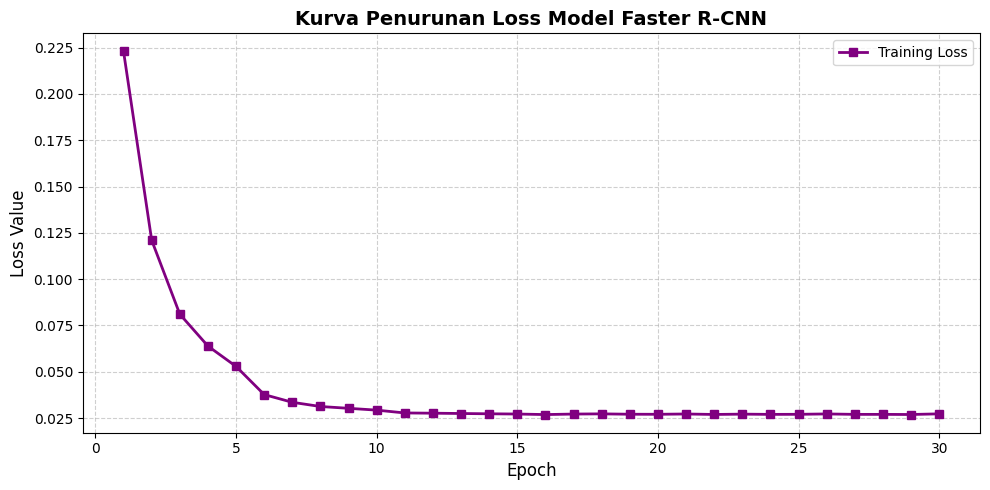

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), history_loss, color='purple', marker='s', linestyle='-', linewidth=2, label='Training Loss')

plt.title('Kurva Penurunan Loss Model Faster R-CNN', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

CELL 5: Visualisasi Confusion Matrix Faster R-CNN

🔄 Membangun Confusion Matrix Faster R-CNN secara manual...



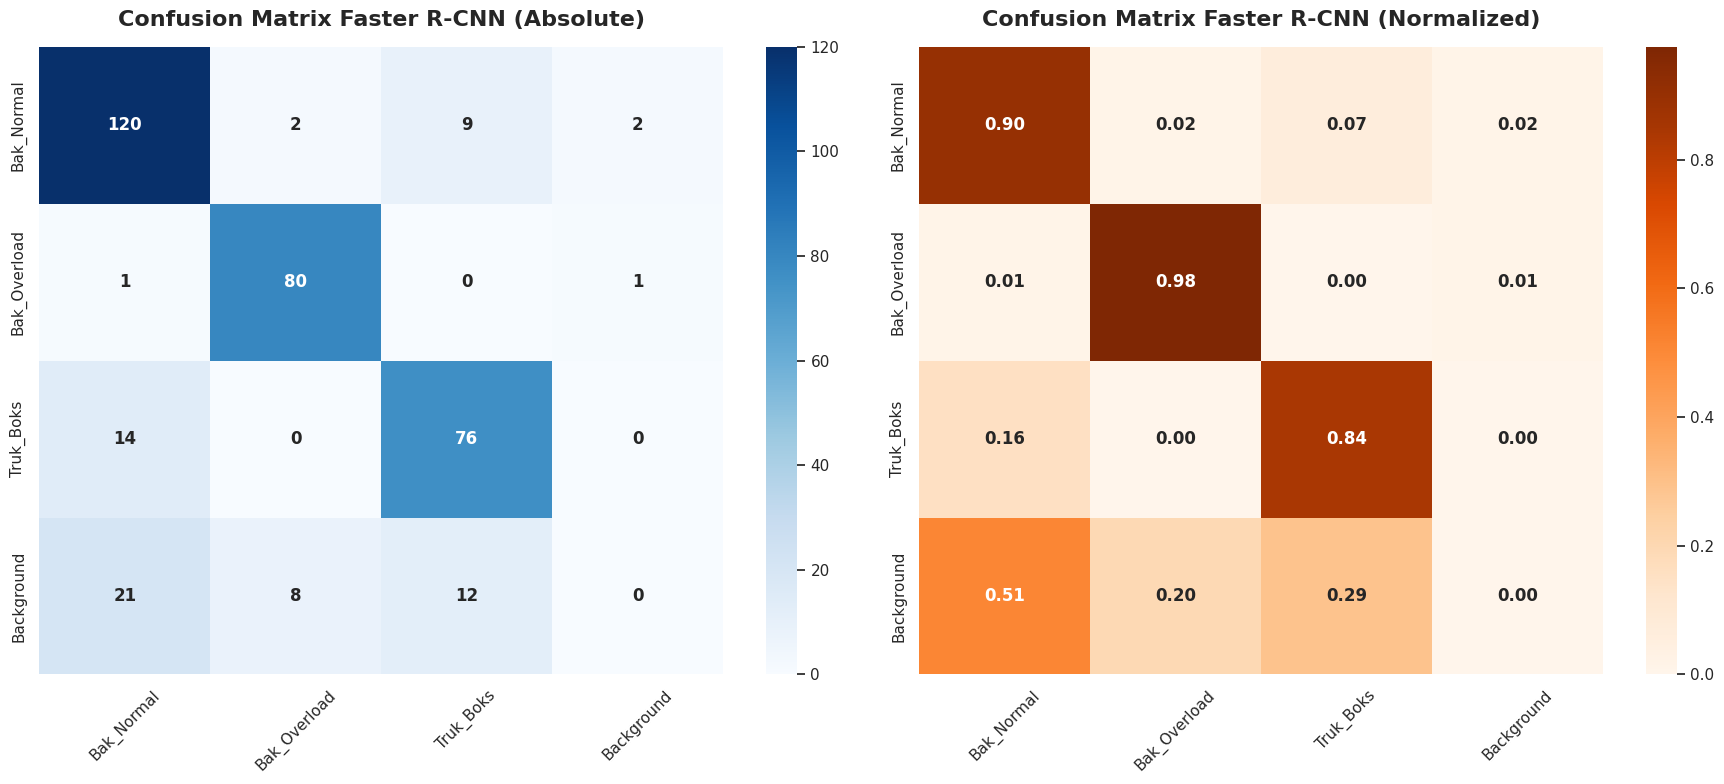

In [ ]:
import torch
import torchvision.ops as ops
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("🔄 Membangun Confusion Matrix Faster R-CNN secara manual...\n")

num_kelas_truk = len(class_names)
ukuran_matriks = num_kelas_truk + 1
conf_matrix = np.zeros((ukuran_matriks, ukuran_matriks), dtype=int)
label_matriks = class_names + ['Background']

CONF_THRESH = 0.5  # Batas keyakinan tebakan
IOU_THRESH = 0.5   # Batas ketepatan kotak

model.eval()
with torch.no_grad():
    for images, targets in test_loader:
        images = list(img.to(device) for img in images)
        preds = model(images)

        for p, t in zip(preds, targets):
            pred_boxes = p["boxes"].cpu()
            pred_scores = p["scores"].cpu()
            pred_labels = p["labels"].cpu() - 1

            gt_boxes = t["boxes"].cpu()
            gt_labels = t["labels"].cpu() - 1

            # Saring tebakan yang skornya di bawah 50%
            keep = pred_scores >= CONF_THRESH
            pred_boxes = pred_boxes[keep]
            pred_labels = pred_labels[keep]

            if len(gt_boxes) == 0 and len(pred_boxes) == 0:
                continue

            # Hitung IoU (Tumpang tindih kotak)
            ious = ops.box_iou(gt_boxes, pred_boxes)
            gt_matched = np.zeros(len(gt_boxes), dtype=bool)
            pred_matched = np.zeros(len(pred_boxes), dtype=bool)

            for gt_idx in range(len(gt_boxes)):
                if len(pred_boxes) == 0:
                    break
                best_iou_idx = torch.argmax(ious[gt_idx]).item()
                best_iou_val = ious[gt_idx][best_iou_idx].item()

                if best_iou_val >= IOU_THRESH and not pred_matched[best_iou_idx]:
                    gl = gt_labels[gt_idx].item()
                    pl = pred_labels[best_iou_idx].item()
                    conf_matrix[gl, pl] += 1
                    gt_matched[gt_idx] = True
                    pred_matched[best_iou_idx] = True

            # Catat False Negatives (Kunci ada, tapi model gagal tebak/mengira background)
            for gt_idx, matched in enumerate(gt_matched):
                if not matched:
                    gl = gt_labels[gt_idx].item()
                    conf_matrix[gl, ukuran_matriks-1] += 1

            # Catat False Positives (Kunci kosong, tapi model menebak ada truk)
            for pred_idx, matched in enumerate(pred_matched):
                if not matched:
                    pl = pred_labels[pred_idx].item()
                    conf_matrix[ukuran_matriks-1, pl] += 1

row_sums = conf_matrix.sum(axis=1, keepdims=True)
conf_matrix_norm = conf_matrix / (row_sums + 1e-6)

# PENGGAMBARAN GRAFIK
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.set_theme(style="white")

# 1. Matriks Absolut (Sebelah Kiri)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=label_matriks, yticklabels=label_matriks,
            annot_kws={"size": 12, "weight": "bold"})
axes[0].set_title('Confusion Matrix Faster R-CNN (Absolute)', fontsize=16, fontweight='bold', pad=15)
axes[0].set_ylabel('')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# 2. Matriks Normalized (Sebelah Kanan)
sns.heatmap(conf_matrix_norm, annot=True, fmt=".2f", cmap="Oranges", ax=axes[1],
            xticklabels=label_matriks, yticklabels=label_matriks,
            annot_kws={"size": 12, "weight": "bold"})
axes[1].set_title('Confusion Matrix Faster R-CNN (Normalized)', fontsize=16, fontweight='bold', pad=15)
axes[1].set_ylabel('')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

CELL 6: Evaluasi Kuantitatif pada Data Uji (Unseen Data)

In [ ]:
import time
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torch.utils.data import DataLoader

print("1. Memanggil 'otak' model terbaik Faster R-CNN...")
# Kita pastikan test_loader sudah dibuat di Cell 3
# Memuat model
path_model_terbaik = f"{folder_simpan_frcnn}/best_frcnn.pth"
model.load_state_dict(torch.load(path_model_terbaik))
model.eval()

print("\n2. Memulai Ujian Akhir pada data TEST...")

# --- TRIK DUA KALKULATOR (Sama seperti SSD) ---
metric_50 = MeanAveragePrecision(iou_type="bbox", class_metrics=True, iou_thresholds=[0.5])
metric_all = MeanAveragePrecision(iou_type="bbox", class_metrics=True)

total_images = len(test_dataset)
instances_per_class = {i+1: 0 for i in range(len(class_names))}

for _, target in test_dataset:
    for label in target['labels']:
        instances_per_class[label.item()] += 1
total_instances = sum(instances_per_class.values())

start_time = time.time()

# Threshold minimal untuk mAP eval (Membuang tebakan sampah/sangat rendah)
CONF_THRESH_EVAL = 0.05

with torch.no_grad():
    for images, targets in test_loader:
        images = list(img.to(device) for img in images)
        preds = model(images)

        preds_metric = []
        for p in preds:
            # Ambil hanya skor di atas Threshold
            keep = p["scores"] >= CONF_THRESH_EVAL
            preds_metric.append({
                "boxes": p["boxes"][keep].cpu(),
                "scores": p["scores"][keep].cpu(),
                "labels": p["labels"][keep].cpu()
            })

        targets_metric = [{"boxes": t["boxes"].cpu(), "labels": t["labels"].cpu()} for t in targets]

        # Masukkan ke dua kalkulator
        metric_50.update(preds_metric, targets_metric)
        metric_all.update(preds_metric, targets_metric)

end_time = time.time()
waktu_inferensi_ms = ((end_time - start_time) / total_images) * 1000

print("Evaluasi selesai, memproses metrik tabel...\n")
hasil_50 = metric_50.compute()
hasil_all = metric_all.compute()

# Ambil nilai Rata-rata
map50_all = hasil_50['map'].item()
map_all = hasil_all['map'].item()
mar_all = hasil_all['mar_100'].item()

# Ambil nilai per Kelas
map50_cls = hasil_50['map_per_class'].tolist()
map_cls = hasil_all['map_per_class'].tolist()
mar_cls = hasil_all['mar_100_per_class'].tolist()

# CETAK TABEL PER KELAS
print(f"{'Class':>20} {'Images':>10} {'Instances':>10} {'mAR(Recall)':>15} {'mAP50':>10} {'mAP50-95':>10}")
print(f"{'all':>20} {total_images:>10} {total_instances:>10} {mar_all:>15.3f} {map50_all:>10.3f} {map_all:>10.3f}")

for i, cls_name in enumerate(class_names):
    if map50_cls[i] != -1:
        print(f"{cls_name:>20} {'-':>10} {instances_per_class[i+1]:>10} {mar_cls[i]:>15.3f} {map50_cls[i]:>10.3f} {map_cls[i]:>10.3f}")

print(f"\nSpeed: {waktu_inferensi_ms:.1f}ms inference per image pada {device.type.upper()}")
print(f"Results saved to {folder_simpan_frcnn}")

print("\n" + "="*50)
print("🎯 EVALUASI TEST FASTER R-CNN SELESAI!")
print("="*50)
print("RANGKUMAN NILAI RATA-RATA (KESELURUHAN KELAS):")
print(f"- Mean Recall (mAR)  : {mar_all:.4f} ({mar_all*100:.2f}%)")
print(f"- mAP@50             : {map50_all:.4f} ({map50_all*100:.2f}%)")
print(f"- mAP@50-95          : {map_all:.4f} ({map_all*100:.2f}%)")
print("="*50)

1. Memanggil 'otak' model terbaik Faster R-CNN...

2. Memulai Ujian Akhir pada data TEST...
Evaluasi selesai, memproses metrik tabel...

               Class     Images  Instances     mAR(Recall)      mAP50   mAP50-95
                 all        214        305           0.902      0.943      0.835
          Bak_Normal          -        133           0.889      0.927      0.817
        Bak_Overload          -         82           0.894      0.976      0.864
           Truk_Boks          -         90           0.924      0.926      0.825

Speed: 118.4ms inference per image pada CUDA
Results saved to /content/drive/MyDrive/Evaluasi_ODOL/FasterRCNN_Hasil

🎯 EVALUASI TEST FASTER R-CNN SELESAI!
RANGKUMAN NILAI RATA-RATA (KESELURUHAN KELAS):
- Mean Recall (mAR)  : 0.9024 (90.24%)
- mAP@50             : 0.9427 (94.27%)
- mAP@50-95          : 0.8353 (83.53%)


CELL 7: Prediksi Visual pada Data Test

1. Mempersiapkan model Faster R-CNN terbaik...
2. Mengambil 8 gambar acak dari data Test...



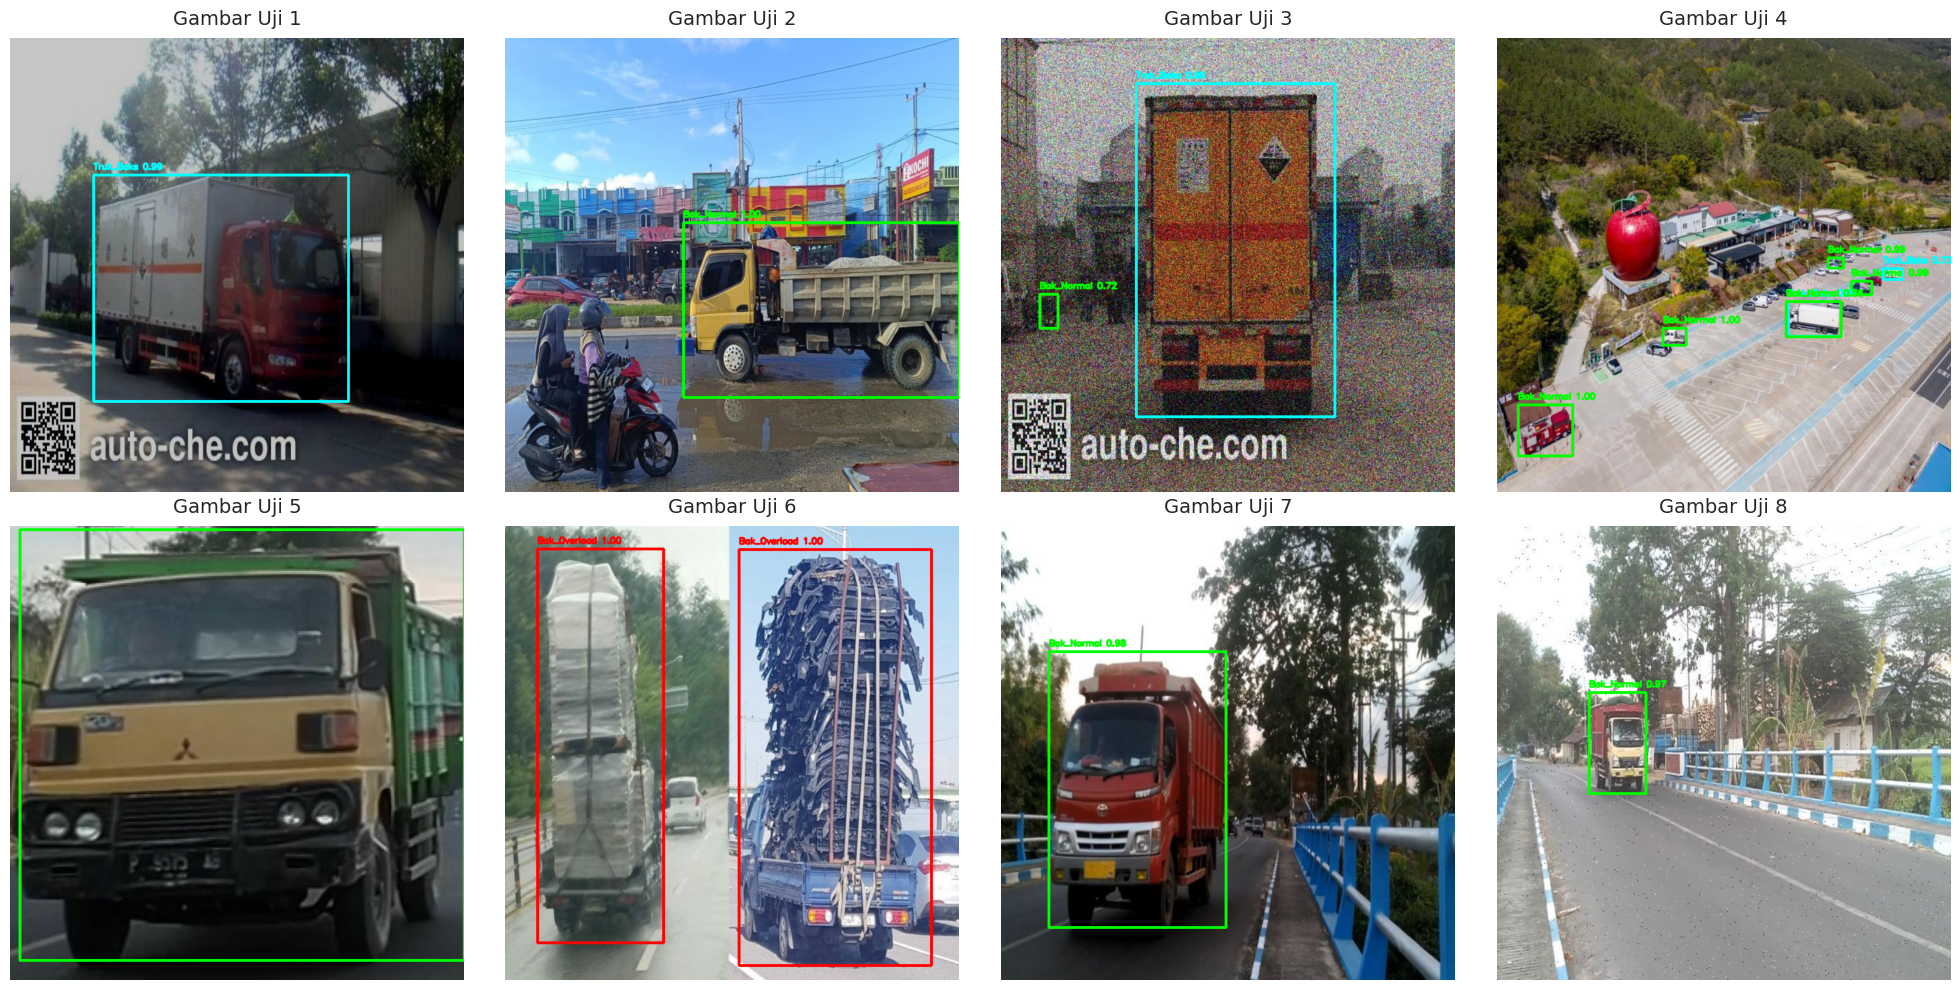


🎯 Prediksi visual Faster R-CNN selesai! Perhatikan apakah kotaknya lebih rapat membungkus objek dibanding SSD/YOLO.


In [ ]:
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

print("1. Mempersiapkan model Faster R-CNN terbaik...")
model.eval()

print("2. Mengambil 8 gambar acak dari data Test...\n")
if len(test_dataset) >= 8:
    indeks_acak = random.sample(range(len(test_dataset)), 8)
else:
    indeks_acak = list(range(len(test_dataset)))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

CONF_THRESH = 0.5 # Batas keyakinan untuk visualisasi
warna_kelas = {
    1: (0, 255, 0),   # Hijau (Bak_Normal)
    2: (255, 0, 0),   # Merah (Bak_Overload)
    3: (0, 255, 255)  # Cyan (Truk_Boks)
}

with torch.no_grad():
    for i, idx in enumerate(indeks_acak):
        # Ambil gambar dari DataLoader
        img_tensor, _ = test_dataset[idx]
        pred = model([img_tensor.to(device)])[0]

        # Konversi tensor gambar ke format Numpy/OpenCV
        img_numpy = img_tensor.permute(1, 2, 0).cpu().numpy()
        img_numpy = (img_numpy * 255).astype(np.uint8)
        img_numpy = np.ascontiguousarray(img_numpy)

        boxes = pred["boxes"].cpu().numpy()
        scores = pred["scores"].cpu().numpy()
        labels = pred["labels"].cpu().numpy()

        # Gambarkan kotak jika skor keyakinan di atas 50%
        for box, score, label in zip(boxes, scores, labels):
            if score >= CONF_THRESH:
                xmin, ymin, xmax, ymax = map(int, box)
                color = warna_kelas.get(label, (255, 255, 0))

                cv2.rectangle(img_numpy, (xmin, ymin), (xmax, ymax), color, 3)
                nama_label = class_names[label - 1]
                label_text = f"{nama_label} {score:.2f}"
                cv2.putText(img_numpy, label_text, (xmin, ymin - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2, cv2.LINE_AA)

        ax = axes[i]
        ax.imshow(img_numpy)
        ax.axis('off')
        ax.set_title(f"Gambar Uji {i+1}", fontsize=14, pad=10)

# Sembunyikan sisa kanvas jika gambar kurang dari 8
for j in range(i + 1, 8):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

print("\n🎯 Prediksi visual Faster R-CNN selesai! Perhatikan apakah kotaknya lebih rapat membungkus objek dibanding SSD/YOLO.")

CELL 8: Deteksi

In [ ]:
import os
import cv2
import torch
import subprocess
import numpy as np
from google.colab import files
from IPython.display import Video, Image as IPyImage, display

print("1. Memuat 'otak' model terbaik Faster R-CNN...")
model.eval()

folder_simpan_bebas = '/content/drive/MyDrive/Evaluasi_ODOL/FasterRCNN_Hasil_Bebas'
os.makedirs(folder_simpan_bebas, exist_ok=True)

print("\n2. Silakan upload file tes kamu (.jpg, .jpeg, .png, .webp, atau .mp4):")
uploaded = files.upload()

if uploaded:
    file_name = list(uploaded.keys())[0]
    input_path = f'/content/{file_name}'
    ext = file_name.rsplit('.', 1)[-1].lower()

    print(f"\n[1/2] Memproses file: {file_name}...")

    CONF_THRESH = 0.5 # Batas keyakinan (Confidence Score)
    warna_kelas = {1: (0, 255, 0), 2: (255, 0, 0), 3: (0, 255, 255)}

    if ext in ['jpg', 'jpeg', 'png', 'webp']:
        # ==============================
        # PROSES JIKA FILE ADALAH FOTO
        # ==============================
        img = cv2.imread(input_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_tensor = torch.tensor(img_rgb.astype(np.float32) / 255.0).permute(2, 0, 1).to(device)

        with torch.no_grad():
            pred = model([img_tensor])[0]

        boxes = pred["boxes"].cpu().numpy()
        scores = pred["scores"].cpu().numpy()
        labels = pred["labels"].cpu().numpy()

        for box, score, label in zip(boxes, scores, labels):
            if score >= CONF_THRESH:
                xmin, ymin, xmax, ymax = map(int, box)
                color = warna_kelas.get(label, (255, 255, 0))
                cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, 3)
                nama_label = class_names[label - 1]
                label_text = f"{nama_label} {score:.2f}"
                cv2.putText(img, label_text, (xmin, ymin - 15), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2, cv2.LINE_AA)

        output_image_path = os.path.join(folder_simpan_bebas, file_name.replace(f'.{ext}', '_FRCNN.jpg'))
        cv2.imwrite(output_image_path, img)

        print("\n" + "="*50)
        print("🎯 PROSES DETEKSI FOTO SELESAI!")
        print("="*50)

        display(IPyImage(filename=output_image_path, width=800))
        print(f"\n✅ File aman tersimpan di: {output_image_path}")

    elif ext in ['mp4', 'avi', 'mov']:
        # ==============================
        # PROSES JIKA FILE ADALAH VIDEO
        # ==============================
        cap = cv2.VideoCapture(input_path)
        fps = cap.get(cv2.CAP_PROP_FPS)
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        nama_tanpa_ext = file_name.rsplit('.', 1)[0]
        avi_path = os.path.join(folder_simpan_bebas, f"{nama_tanpa_ext}_temp.avi")
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        out = cv2.VideoWriter(avi_path, fourcc, fps, (w, h))

        with torch.no_grad():
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret: break

                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                img_tensor = torch.tensor(frame_rgb.astype(np.float32) / 255.0).permute(2, 0, 1).to(device)
                pred = model([img_tensor])[0]

                boxes = pred["boxes"].cpu().numpy()
                scores = pred["scores"].cpu().numpy()
                labels = pred["labels"].cpu().numpy()

                for box, score, label in zip(boxes, scores, labels):
                    if score >= CONF_THRESH:
                        xmin, ymin, xmax, ymax = map(int, box)
                        color = warna_kelas.get(label, (255, 255, 0))
                        cv2.rectangle(frame, (xmin, ymin), (xmax, ymax), color, 3)
                        nama_label = class_names[label - 1]
                        label_text = f"{nama_label} {score:.2f}"
                        cv2.putText(frame, label_text, (xmin, ymin - 15), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv2.LINE_AA)
                out.write(frame)

        cap.release()
        out.release()

        print("[2/2] Mengonversi video agar bisa diputar di Colab...")
        mp4_final_path = os.path.join(folder_simpan_bebas, f"{nama_tanpa_ext}_FINAL_FRCNN.mp4")
        if os.path.exists(mp4_final_path): os.remove(mp4_final_path)

        subprocess.run([
            'ffmpeg', '-y', '-i', avi_path, '-vcodec', 'libx264', '-crf', '25', mp4_final_path, '-loglevel', 'quiet'
        ])

        if os.path.exists(avi_path): os.remove(avi_path)

        print("\n" + "="*50)
        print("🎯 PROSES DETEKSI VIDEO SELESAI!")
        print("="*50)

        display(Video(mp4_final_path, embed=True, width=600))
        print(f"\n✅ Video aman tersimpan permanen di: {mp4_final_path}")
    else:
        print("❌ Format file tidak dikenali. Harap upload gambar atau video yang sesuai.")
else:
    print("Upload dibatalkan.")

1. Memuat 'otak' model terbaik Faster R-CNN...

2. Silakan upload file tes kamu (.jpg, .jpeg, .png, .webp, atau .mp4):


Saving contoh tes.mp4 to contoh tes.mp4

[1/2] Memproses file: contoh tes.mp4...
[2/2] Mengonversi video agar bisa diputar di Colab...

🎯 PROSES DETEKSI VIDEO SELESAI!



✅ Video aman tersimpan permanen di: /content/drive/MyDrive/Evaluasi_ODOL/FasterRCNN_Hasil_Bebas/contoh tes_FINAL_FRCNN.mp4


1. Memuat 'otak' model terbaik Faster R-CNN...

2. Silakan upload file tes kamu (.jpg, .jpeg, .png, .webp, atau .mp4):


Saving truk-box-truk-engkel-dan-truk-wingbox-cover.jpg to truk-box-truk-engkel-dan-truk-wingbox-cover.jpg

[1/2] Memproses file: truk-box-truk-engkel-dan-truk-wingbox-cover.jpg...

🎯 PROSES DETEKSI FOTO SELESAI!


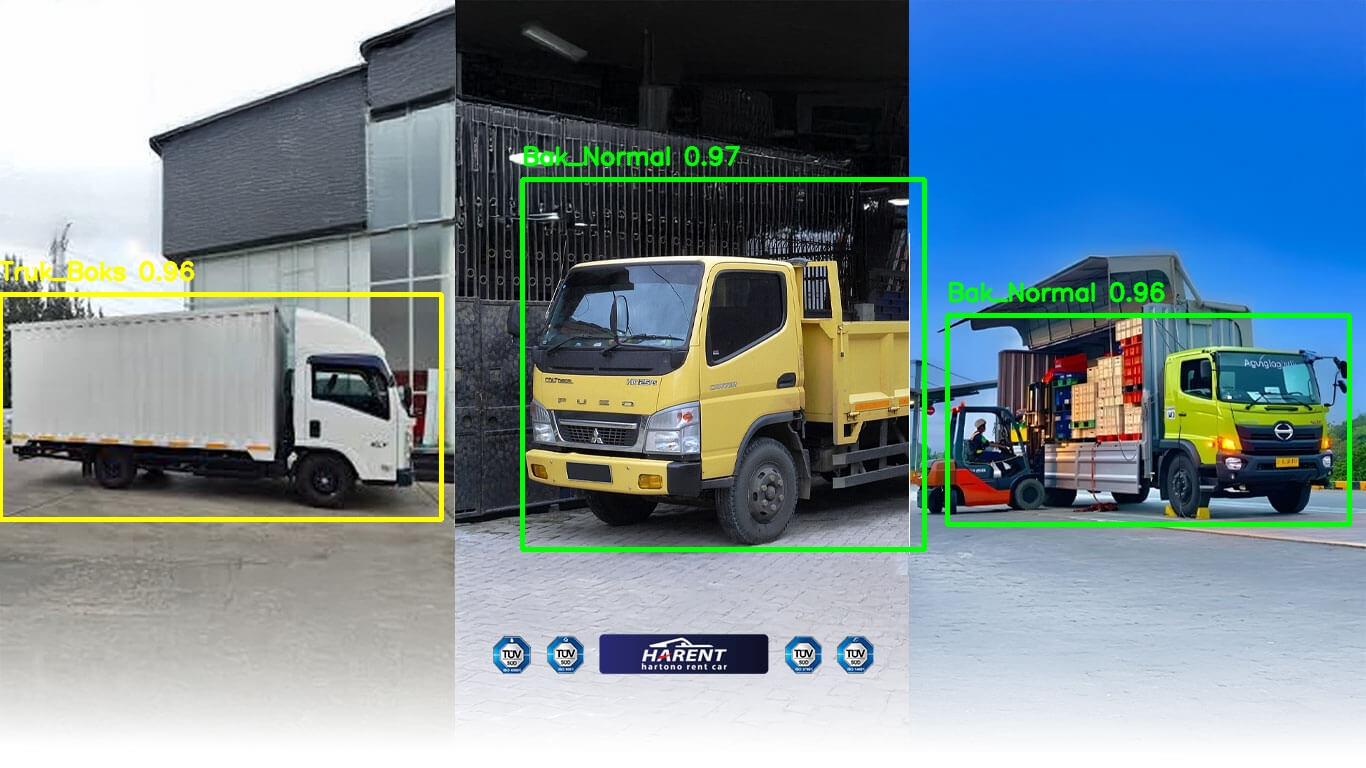


✅ File aman tersimpan di: /content/drive/MyDrive/Evaluasi_ODOL/FasterRCNN_Hasil_Bebas/truk-box-truk-engkel-dan-truk-wingbox-cover_FRCNN.jpg


In [ ]:
import os
import cv2
import torch
import subprocess
import numpy as np
from google.colab import files
from IPython.display import Video, Image as IPyImage, display

print("1. Memuat 'otak' model terbaik Faster R-CNN...")
model.eval()

folder_simpan_bebas = '/content/drive/MyDrive/Evaluasi_ODOL/FasterRCNN_Hasil_Bebas'
os.makedirs(folder_simpan_bebas, exist_ok=True)

print("\n2. Silakan upload file tes kamu (.jpg, .jpeg, .png, .webp, atau .mp4):")
uploaded = files.upload()

if uploaded:
    file_name = list(uploaded.keys())[0]
    input_path = f'/content/{file_name}'
    ext = file_name.rsplit('.', 1)[-1].lower()

    print(f"\n[1/2] Memproses file: {file_name}...")

    CONF_THRESH = 0.5 # Batas keyakinan (Confidence Score)
    warna_kelas = {1: (0, 255, 0), 2: (255, 0, 0), 3: (0, 255, 255)}

    if ext in ['jpg', 'jpeg', 'png', 'webp']:
        # ==============================
        # PROSES JIKA FILE ADALAH FOTO
        # ==============================
        img = cv2.imread(input_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_tensor = torch.tensor(img_rgb.astype(np.float32) / 255.0).permute(2, 0, 1).to(device)

        with torch.no_grad():
            pred = model([img_tensor])[0]

        boxes = pred["boxes"].cpu().numpy()
        scores = pred["scores"].cpu().numpy()
        labels = pred["labels"].cpu().numpy()

        for box, score, label in zip(boxes, scores, labels):
            if score >= CONF_THRESH:
                xmin, ymin, xmax, ymax = map(int, box)
                color = warna_kelas.get(label, (255, 255, 0))
                cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, 3)
                nama_label = class_names[label - 1]
                label_text = f"{nama_label} {score:.2f}"
                cv2.putText(img, label_text, (xmin, ymin - 15), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2, cv2.LINE_AA)

        output_image_path = os.path.join(folder_simpan_bebas, file_name.replace(f'.{ext}', '_FRCNN.jpg'))
        cv2.imwrite(output_image_path, img)

        print("\n" + "="*50)
        print("🎯 PROSES DETEKSI FOTO SELESAI!")
        print("="*50)

        display(IPyImage(filename=output_image_path, width=800))
        print(f"\n✅ File aman tersimpan di: {output_image_path}")

    elif ext in ['mp4', 'avi', 'mov']:
        # ==============================
        # PROSES JIKA FILE ADALAH VIDEO
        # ==============================
        cap = cv2.VideoCapture(input_path)
        fps = cap.get(cv2.CAP_PROP_FPS)
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        nama_tanpa_ext = file_name.rsplit('.', 1)[0]
        avi_path = os.path.join(folder_simpan_bebas, f"{nama_tanpa_ext}_temp.avi")
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        out = cv2.VideoWriter(avi_path, fourcc, fps, (w, h))

        with torch.no_grad():
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret: break

                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                img_tensor = torch.tensor(frame_rgb.astype(np.float32) / 255.0).permute(2, 0, 1).to(device)
                pred = model([img_tensor])[0]

                boxes = pred["boxes"].cpu().numpy()
                scores = pred["scores"].cpu().numpy()
                labels = pred["labels"].cpu().numpy()

                for box, score, label in zip(boxes, scores, labels):
                    if score >= CONF_THRESH:
                        xmin, ymin, xmax, ymax = map(int, box)
                        color = warna_kelas.get(label, (255, 255, 0))
                        cv2.rectangle(frame, (xmin, ymin), (xmax, ymax), color, 3)
                        nama_label = class_names[label - 1]
                        label_text = f"{nama_label} {score:.2f}"
                        cv2.putText(frame, label_text, (xmin, ymin - 15), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv2.LINE_AA)
                out.write(frame)

        cap.release()
        out.release()

        print("[2/2] Mengonversi video agar bisa diputar di Colab...")
        mp4_final_path = os.path.join(folder_simpan_bebas, f"{nama_tanpa_ext}_FINAL_FRCNN.mp4")
        if os.path.exists(mp4_final_path): os.remove(mp4_final_path)

        subprocess.run([
            'ffmpeg', '-y', '-i', avi_path, '-vcodec', 'libx264', '-crf', '25', mp4_final_path, '-loglevel', 'quiet'
        ])

        if os.path.exists(avi_path): os.remove(avi_path)

        print("\n" + "="*50)
        print("🎯 PROSES DETEKSI VIDEO SELESAI!")
        print("="*50)

        display(Video(mp4_final_path, embed=True, width=600))
        print(f"\n✅ Video aman tersimpan permanen di: {mp4_final_path}")
    else:
        print("❌ Format file tidak dikenali. Harap upload gambar atau video yang sesuai.")
else:
    print("Upload dibatalkan.")

CELL 9: Persiapan Ekspor

In [ ]:
from google.colab import files
import os

print("Mencari file model terbaik Faster R-CNN di Google Drive...")

path_model_frcnn = f"{folder_simpan_frcnn}/best_frcnn.pth"

if os.path.exists(path_model_frcnn):
    print("✅ File 'best_frcnn.pth' ditemukan! Memulai proses unduh...")
    files.download(path_model_frcnn)
    print("📥 Tunggu sebentar, file sedang diunduh. Silakan cek folder 'Downloads' di laptop Anda nanti.")
else:
    print("❌ Model tidak ditemukan. Pastikan proses training di Cell 4 sudah tuntas dan tersimpan.")

Mencari file model terbaik Faster R-CNN di Google Drive...
✅ File 'best_frcnn.pth' ditemukan! Memulai proses unduh...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Tunggu sebentar, file sedang diunduh. Silakan cek folder 'Downloads' di laptop Anda nanti.
